<a href="https://colab.research.google.com/github/Fran7373/Machine-Learning-Class-2026-1/blob/main/Exercise1_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1.10 — Hoeffding Inequality & Multiple Bins

This notebook illustrates **why the Hoeffding inequality does not apply to the coin selected by an adaptive rule** (like picking the one with the minimum number of heads), even though it does apply to a single pre-specified coin.

**Setup:**
- Flip **1,000 fair coins**, each **10 times**.
- Focus on three coins:
  - $c_1$: the **first** coin flipped.
  - $c_{rand}$: a **randomly chosen** coin.
  - $c_{min}$: the coin with the **minimum frequency of heads** (ties broken by earlier index).
- $\nu_1$, $\nu_{rand}$, $\nu_{min}$: fraction of heads for the respective coins.
- True $\mu = 0.5$ for all coins (fair).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec




N_COINS   = 1_000
N_FLIPS   = 10
N_RUNS    = 100_000
MU        = 0.5

print(f"Running {N_RUNS:,} experiments — {N_COINS:,} coins × {N_FLIPS} flips each")

Running 100,000 experiments — 1,000 coins × 10 flips each


## (a) What is μ for the three coins?

All 1,000 coins are **fair**, so:

$$\mu_1 = \mu_{rand} = \mu_{min} = 0.5$$

The key insight is that **μ is the same for every coin** — what differs is the *distribution of ν* after the selection rule is applied.

## (b) Simulate and collect ν₁, ν_rand, ν_min

In [ ]:
# Simulate in batches to keep memory usage low (~50 MB instead of 7 GB)
BATCH = 1000  # runs per batch

nu_1    = np.empty(N_RUNS)
nu_rand = np.empty(N_RUNS)
nu_min  = np.empty(N_RUNS)

for start in range(0, N_RUNS, BATCH):
    end = min(start + BATCH, N_RUNS)
    b = end - start
    # Shape: (b, N_COINS, N_FLIPS) — int8 saves 8x memory vs int64
    flips = np.random.randint(0, 2, size=(b, N_COINS, N_FLIPS), dtype=np.int8)
    freq  = flips.mean(axis=2)  # shape: (b, N_COINS)

    nu_1[start:end]    = freq[:, 0]
    rand_idx           = np.random.randint(0, N_COINS, size=b)
    nu_rand[start:end] = freq[np.arange(b), rand_idx]
    min_idx            = np.argmin(freq, axis=1)
    nu_min[start:end]  = freq[np.arange(b), min_idx]

print(f'ν₁    — mean={nu_1.mean():.4f}, std={nu_1.std():.4f}')
print(f'ν_rand — mean={nu_rand.mean():.4f}, std={nu_rand.std():.4f}')
print(f'ν_min  — mean={nu_min.mean():.4f}, std={nu_min.std():.4f}')

ν₁    — mean=0.4998, std=0.1583
ν_rand — mean=0.5006, std=0.1586
ν_min  — mean=0.0378, std=0.0485


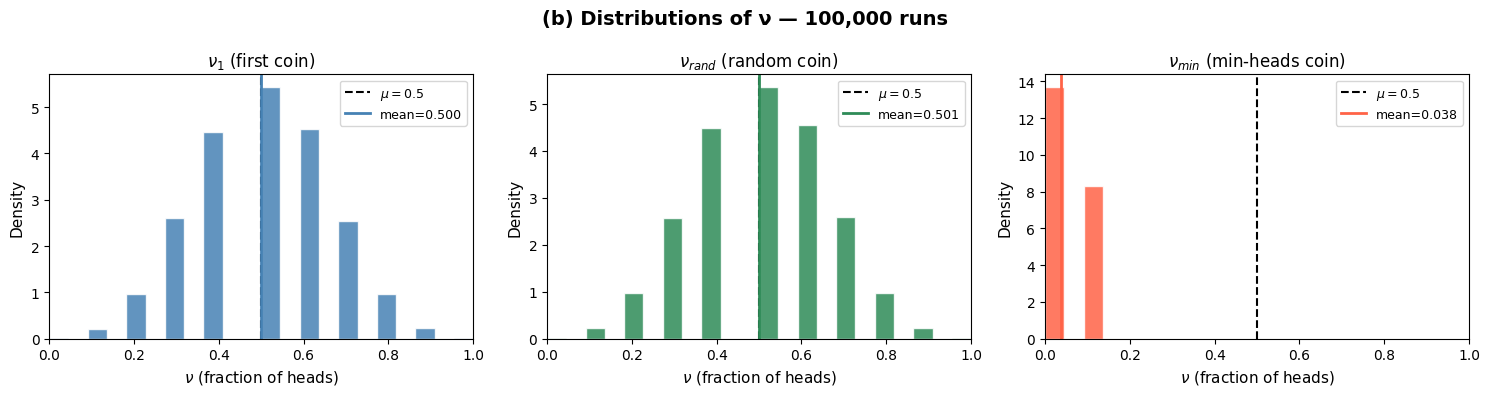

In [ ]:
# ── Plot histograms ──────────────────────────────────────────────────────────
bins = np.linspace(0, 1, 23)  # 0, 0.1, 0.2, ... 1.0 (steps of 1/N_FLIPS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("(b) Distributions of ν — 100,000 runs", fontsize=14, fontweight='bold')

data   = [nu_1,    nu_rand,  nu_min]
labels = [r'$\nu_1$ (first coin)', r'$\nu_{rand}$ (random coin)', r'$\nu_{min}$ (min-heads coin)']
colors = ['steelblue', 'seagreen', 'tomato']

for ax, nu, label, color in zip(axes, data, labels, colors):
    ax.hist(nu, bins=bins, color=color, edgecolor='white', alpha=0.85, density=True)
    ax.axvline(MU, color='black', linestyle='--', linewidth=1.5, label=r'$\mu=0.5$')
    ax.axvline(nu.mean(), color=color, linestyle='-', linewidth=2,
               label=f'mean={nu.mean():.3f}')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(r'$\nu$ (fraction of heads)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


**Observations:**
- $\nu_1$ and $\nu_{rand}$ are roughly **symmetric around 0.5** — consistent with a fair coin.
- $\nu_{min}$ is **heavily skewed left** — it almost always takes small values (near 0), even though $\mu_{min} = 0.5$.

## (c) Empirical P[|ν − μ| > ε] vs. Hoeffding bound

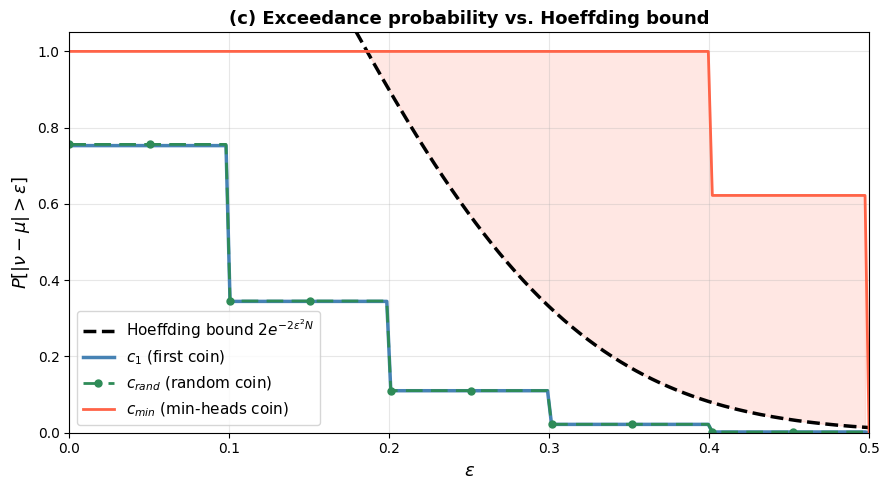

In [ ]:
epsilons = np.linspace(0, 0.5, 200)

def exceedance_prob(nu, mu, eps_vals):
    """Empirical P[|ν - μ| > ε] for each ε."""
    return np.array([(np.abs(nu - mu) > e).mean() for e in eps_vals])

# Hoeffding bound: 2 * exp(-2 * ε² * N)
hoeffding = 2 * np.exp(-2 * epsilons**2 * N_FLIPS)

p_1    = exceedance_prob(nu_1,    MU, epsilons)
p_rand = exceedance_prob(nu_rand, MU, epsilons)
p_min  = exceedance_prob(nu_min,  MU, epsilons)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(epsilons, hoeffding, 'k--', linewidth=2.5, label='Hoeffding bound $2e^{-2\\varepsilon^2 N}$')
ax.plot(epsilons, p_1,    color='steelblue', linewidth=2.5,
        linestyle='-',  label=r'$c_1$ (first coin)')
ax.plot(epsilons, p_rand, color='seagreen',  linewidth=2,
        linestyle='--', dashes=(6,3), marker='o', markevery=20,
        markersize=5,   label=r'$c_{rand}$ (random coin)')
ax.plot(epsilons, p_min,  color='tomato',    linewidth=2, label=r'$c_{min}$ (min-heads coin)')

ax.set_xlabel(r'$\varepsilon$', fontsize=13)
ax.set_ylabel(r'$P[|\nu - \mu| > \varepsilon]$', fontsize=13)
ax.set_title('(c) Exceedance probability vs. Hoeffding bound', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)


ax.fill_between(epsilons, hoeffding, p_min,
                where=(p_min > hoeffding),
                color='tomato', alpha=0.15, label='Hoeffding violated')

plt.tight_layout()

plt.show()


## (d) Which coins obey the Hoeffding bound?



| Coin | Hoeffding? | Reason |
|------|-----------|--------|
| $c_1$ (first) | ✅ **Obeys** | Fixed *before* seeing any data. Hoeffding applies to any single pre-specified bin. |
| $c_{rand}$ (random) | ✅ **Obeys** | Chosen independently of outcomes. Statistically equivalent to $c_1$. |
| $c_{min}$ (min heads) | ❌ **Violates** | Chosen *adaptively* — by design it is the coin most biased toward tails. This introduces a systematic selection bias. |

**Why does $c_{min}$ violate Hoeffding?**  
Hoeffding's inequality assumes the hypothesis (coin) is fixed **independently of the sample**. When we pick $c_{min}$ *after* seeing all results, we are effectively scanning 1,000 coins and selecting the most extreme one. The chance that *at least one* of 1,000 coins shows a large deviation from 0.5 is much higher than the chance for any single pre-fixed coin — this is the **multiple-testing / multiple-bins** problem.

Formally, let $M=1000$ coins. The probability that the *minimum* deviates by more than $\varepsilon$ satisfies:
$$P\left[\nu_{min} \leq \mu - \varepsilon\right] \;\leq\; M \cdot e^{-2\varepsilon^2 N}$$
which can be much larger than $2e^{-2\varepsilon^2 N}$ for small $\varepsilon$.

## (e) Connection to Multiple Bins

This experiment is a concrete illustration of the **multiple-bins** (multiple hypotheses) problem from learning theory.

### Single bin (one hypothesis)
If we fix **one hypothesis** $h$ *before* observing data and compute its training error $E_{in}(h)$, the Hoeffding inequality guarantees:
$$P\left[|E_{in}(h) - E_{out}(h)| > \varepsilon\right] \leq 2e^{-2\varepsilon^2 N}$$
This is exactly what $c_1$ and $c_{rand}$ demonstrate — the bound holds.

### Multiple bins ($M$ hypotheses)
In practice, a learning algorithm explores a **hypothesis set** $\mathcal{H} = \{h_1, \ldots, h_M\}$ and returns the hypothesis $g$ with **minimum in-sample error** — analogous to choosing $c_{min}$.

A union bound gives:
$$P\left[\exists h_m: |E_{in}(h_m) - E_{out}(h_m)| > \varepsilon\right] \leq \sum_{m=1}^{M} P\left[|E_{in}(h_m) - E_{out}(h_m)| > \varepsilon\right] \leq 2Me^{-2\varepsilon^2 N}$$

The correct Hoeffding-like bound for $g$ (chosen adaptively) is therefore:
$$P\left[|E_{in}(g) - E_{out}(g)| > \varepsilon\right] \leq 2Me^{-2\varepsilon^2 N}$$




 The naïve Hoeffding bound is only valid when the hypothesis is chosen *independently* of the data. When the hypothesis is selected by minimizing training error over many candidates, the training error is an **optimistic (biased) estimate** of the true error — the gap is larger, and a correction factor of $M$ (or eventually the VC dimension) is needed.

/tmp/ipykernel_22563/3426634226.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-." (-> color='k'). The keyword argument will take precedence.
  ax.plot(epsilons, hoeffding_multi,   'k-.', color="m",linewidth=3.0, label=f'Multi-bin Hoeffding $2\\cdot {M}\\cdot e^{{-2\\varepsilon^2 N}}$ (clipped at 1)')


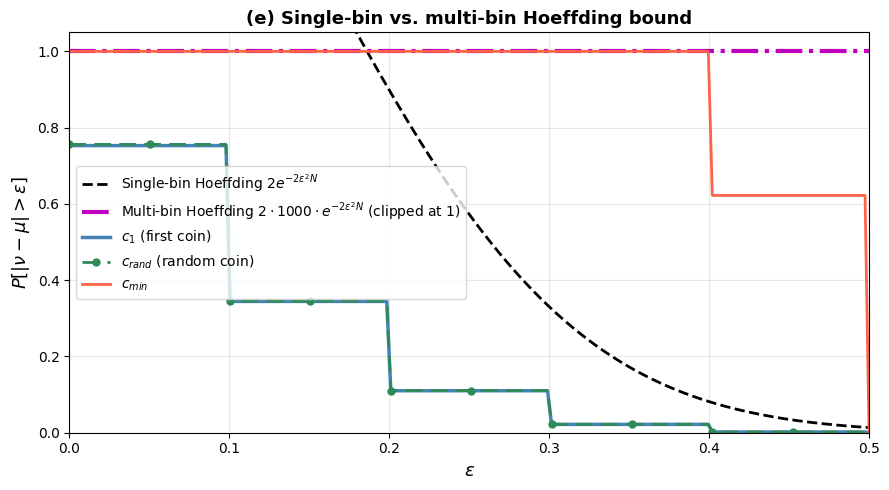

In [ ]:

M = N_COINS
hoeffding_multi = np.minimum(1.0, 2 * M * np.exp(-2 * epsilons**2 * N_FLIPS))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(epsilons, hoeffding,      'k--', linewidth=2.0, label='Single-bin Hoeffding $2e^{-2\\varepsilon^2 N}$')
ax.plot(epsilons, hoeffding_multi,   'k-.', color="m",linewidth=3.0, label=f'Multi-bin Hoeffding $2\\cdot {M}\\cdot e^{{-2\\varepsilon^2 N}}$ (clipped at 1)')
ax.plot(epsilons, p_1,    color='steelblue', linewidth=2.5,
        linestyle='-',  label=r'$c_1$ (first coin)')
ax.plot(epsilons, p_rand, color='seagreen',  linewidth=2,
        linestyle='--', dashes=(6,3), marker='o', markevery=20,
        markersize=5,   label=r'$c_{rand}$ (random coin)')
ax.plot(epsilons, p_min,  color='tomato',    linewidth=2, label=r'$c_{min}$')

ax.set_xlabel(r'$\varepsilon$', fontsize=13)
ax.set_ylabel(r'$P[|\nu - \mu| > \varepsilon]$', fontsize=13)
ax.set_title('(e) Single-bin vs. multi-bin Hoeffding bound', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


**The multi-bin bound (dashed-dot line) correctly upper-bounds $c_{min}$**, confirming that selecting the worst-performing coin is equivalent to a learning algorithm that searches over $M$ hypotheses.